# Loop Design Playbook — Quantitative Demos

> Simulations behind the design rules in [loop_design_playbook.md](loop_design_playbook.md):
> why verified retries beat single sessions, how to size iteration budgets, why the verifier's
> false-pass rate is the number that matters, where the prompt-cache cost cliff sits, and how
> four weekly ops metrics expose a silently degrading loop.

All experiments use numpy + matplotlib only (core dependencies).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
plt.rcParams["figure.dpi"] = 100
print("numpy:", np.__version__)

numpy: 2.4.6


## 1. The retry distribution — why loops beat sessions

A loop iteration succeeds against the verifier with probability $p$. Iterations to first
success follow a geometric distribution: $\mathbb{E}[N] = 1/p$ and
$P(\text{success within } k) = 1 - (1-p)^k$.

A human runs 1–3 attempts per sitting. A loop runs until the cap. The gap between those two
regimes is the entire value proposition of loop engineering.

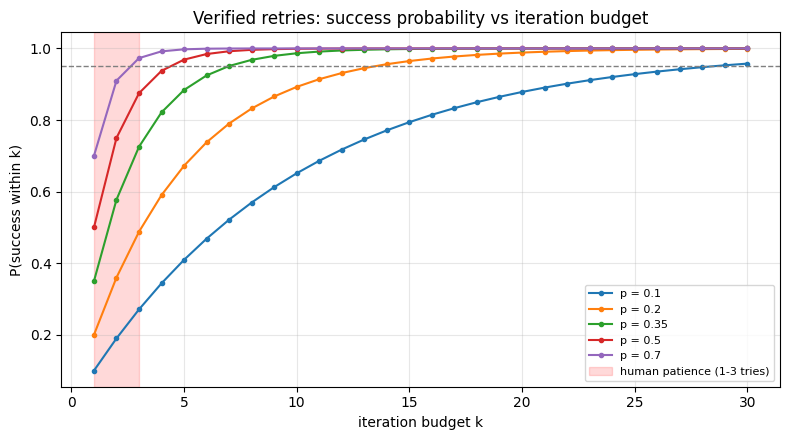

p= 0.1: E[N]= 10.0   iterations for 95% success: 29
p= 0.2: E[N]=  5.0   iterations for 95% success: 14
p=0.35: E[N]=  2.9   iterations for 95% success: 7
p= 0.5: E[N]=  2.0   iterations for 95% success: 5
p= 0.7: E[N]=  1.4   iterations for 95% success: 3


In [2]:
ks = np.arange(1, 31)
ps = [0.1, 0.2, 0.35, 0.5, 0.7]

fig, ax = plt.subplots(figsize=(8, 4.5))
for p in ps:
    ax.plot(ks, 1 - (1 - p) ** ks, marker=".", label=f"p = {p}")
ax.axvspan(1, 3, alpha=0.15, color="red", label="human patience (1-3 tries)")
ax.axhline(0.95, ls="--", c="gray", lw=1)
ax.set_xlabel("iteration budget k")
ax.set_ylabel("P(success within k)")
ax.set_title("Verified retries: success probability vs iteration budget")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

for p in ps:
    k95 = int(np.ceil(np.log(0.05) / np.log(1 - p)))
    print(f"p={p:>4}: E[N]={1/p:5.1f}   iterations for 95% success: {k95}")

**Reading**: a task the agent one-shots only 20% of the time reaches 95% success at 14
verified iterations — far beyond interactive patience, trivial for an overnight loop.
This is why "output one person cannot produce" needs no smarter model, only loop structure.

## 2. Sizing the iteration budget

From the playbook (Section 4): to succeed with probability $q$ given one-shot rate $p$, cap at

$$k \geq \frac{\ln(1-q)}{\ln(1-p)}$$

If the loop hits the cap, the task was mis-scoped — decompose it, don't raise the cap.
We verify the formula with Monte Carlo.

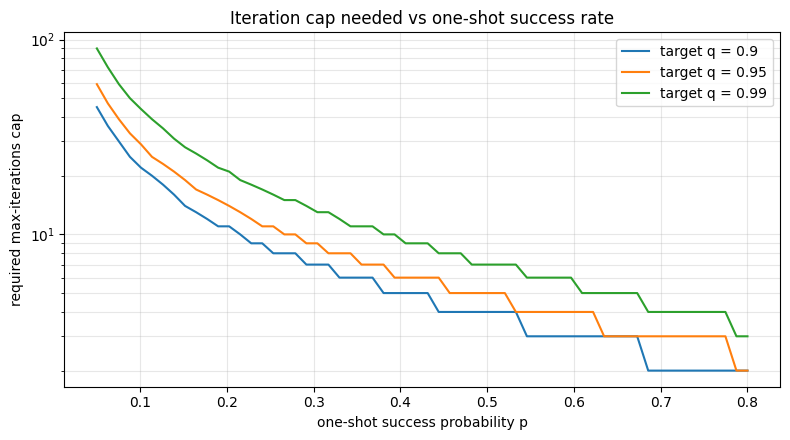

p=0.25, q=0.95 -> analytic cap = 11
Monte Carlo P(success within 11) = 0.9577  (target >= 0.95)


In [3]:
def required_cap(p, q):
    return int(np.ceil(np.log(1 - q) / np.log(1 - p)))

p_grid = np.linspace(0.05, 0.8, 60)
fig, ax = plt.subplots(figsize=(8, 4.5))
for q in [0.90, 0.95, 0.99]:
    ax.plot(p_grid, [required_cap(p, q) for p in p_grid], label=f"target q = {q}")
ax.set_xlabel("one-shot success probability p")
ax.set_ylabel("required max-iterations cap")
ax.set_yscale("log")
ax.set_title("Iteration cap needed vs one-shot success rate")
ax.legend()
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

# Monte Carlo check for p=0.25, q=0.95
p, q = 0.25, 0.95
cap = required_cap(p, q)
trials = rng.random((200_000, cap)) < p
success = trials.any(axis=1).mean()
print(f"p={p}, q={q} -> analytic cap = {cap}")
print(f"Monte Carlo P(success within {cap}) = {success:.4f}  (target >= {q})")

## 3. The verifier is the product — false passes at loop volume

The verifier accepts bad units at false-pass rate $\beta$ and rejects good ones at
false-block rate $\alpha$. The probability a *shipped* unit is defective:

$$P(\text{defective} \mid \text{shipped}) =
\frac{(1-p)\,\beta}{p\,(1-\alpha) + (1-p)\,\beta}$$

Loops create volume, so a defect rate tolerable at human pace becomes intolerable at loop
pace. Meanwhile $\alpha$ only wastes iterations — the cheap failure direction.

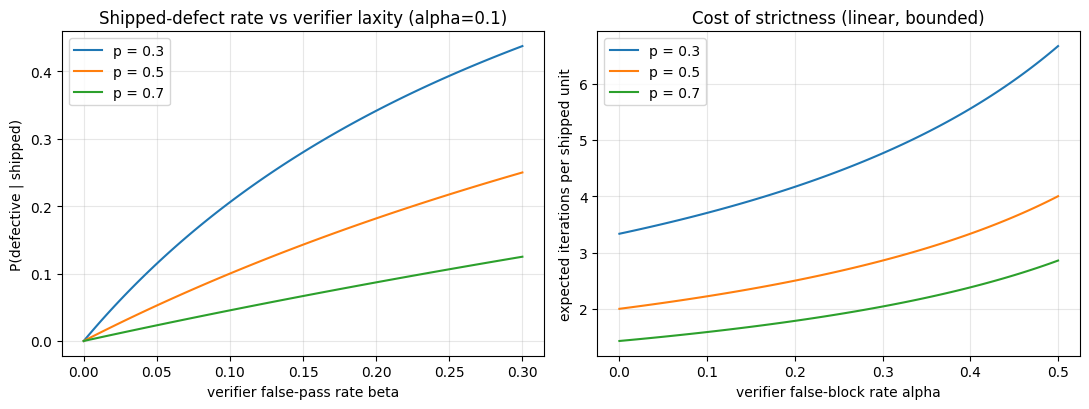

beta=0.02: shipped-defect rate =  2.2%  -> silent defects/week at 30 units:  0.7
beta=0.05: shipped-defect rate =  5.3%  -> silent defects/week at 30 units:  1.6
beta=0.10: shipped-defect rate = 10.0%  -> silent defects/week at 30 units:  3.0
beta=0.20: shipped-defect rate = 18.2%  -> silent defects/week at 30 units:  5.5


In [4]:
def shipped_defect_rate(p, alpha, beta):
    return ((1 - p) * beta) / (p * (1 - alpha) + (1 - p) * beta)

betas = np.linspace(0.0, 0.3, 100)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

for p in [0.3, 0.5, 0.7]:
    axes[0].plot(betas, shipped_defect_rate(p, 0.1, betas), label=f"p = {p}")
axes[0].set_xlabel("verifier false-pass rate beta")
axes[0].set_ylabel("P(defective | shipped)")
axes[0].set_title("Shipped-defect rate vs verifier laxity (alpha=0.1)")
axes[0].legend(); axes[0].grid(alpha=0.3)

# cost of strictness: expected verified iterations ~ 1 / (p * (1 - alpha))
alphas = np.linspace(0.0, 0.5, 100)
for p in [0.3, 0.5, 0.7]:
    axes[1].plot(alphas, 1 / (p * (1 - alphas)), label=f"p = {p}")
axes[1].set_xlabel("verifier false-block rate alpha")
axes[1].set_ylabel("expected iterations per shipped unit")
axes[1].set_title("Cost of strictness (linear, bounded)")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

units_per_week = 30
for beta in [0.02, 0.05, 0.10, 0.20]:
    r = shipped_defect_rate(0.5, 0.1, beta)
    print(f"beta={beta:.2f}: shipped-defect rate = {r:5.1%}"
          f"  -> silent defects/week at 30 units: {units_per_week * r:4.1f}")

**Reading**: moving $\beta$ from 2% to 20% takes weekly silent defects from ~0.6 to ~5 at a
volume of 30 units. Strictness ($\alpha$) only raises cost linearly. When tuning a reviewer
agent, bias it strict — and prefer deterministic verifiers (tests, schemas) whose $\beta$ is
near zero by construction.

## 4. Polling cost and the prompt-cache cliff

Polling loops re-read their context every wake-up. With a prompt cache (TTL ~5 min, cached
reads ~0.1x price), polling *faster* than the TTL keeps context cheap; polling between 5 and
~20 minutes pays a full-price re-read each time without amortizing it over a long sleep.

Model: context $C$ tokens, fresh price 1.0/token, cached price 0.1/token, TTL 300 s.

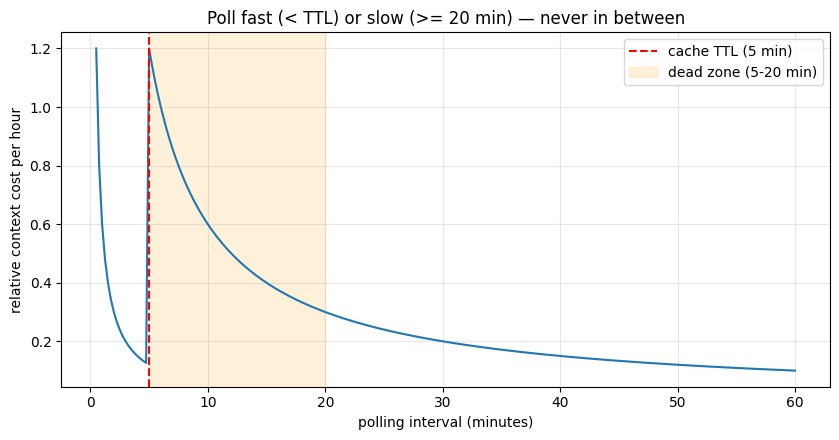

poll every  2.0 min: cost/hour =   0.30
poll every  4.5 min: cost/hour =   0.13
poll every  6.0 min: cost/hour =   1.00
poll every 10.0 min: cost/hour =   0.60
poll every 30.0 min: cost/hour =   0.20


In [5]:
C = 100_000          # context tokens re-read per poll
TTL = 300            # cache TTL, seconds
fresh, cached = 1.0, 0.1   # relative price per token

intervals = np.arange(30, 3601, 15)          # polling interval in seconds
polls_per_hour = 3600 / intervals
price = np.where(intervals < TTL, cached, fresh)
cost_per_hour = polls_per_hour * C * price / 1e6   # arbitrary cost units

fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.plot(intervals / 60, cost_per_hour)
ax.axvline(TTL / 60, ls="--", c="red", label="cache TTL (5 min)")
ax.axvspan(TTL / 60, 20, alpha=0.15, color="orange", label="dead zone (5-20 min)")
ax.set_xlabel("polling interval (minutes)")
ax.set_ylabel("relative context cost per hour")
ax.set_title("Poll fast (< TTL) or slow (>= 20 min) — never in between")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

for m in [2, 4.5, 6, 10, 30]:
    s = m * 60
    p_price = cached if s < TTL else fresh
    print(f"poll every {m:>4.1f} min: cost/hour = {3600/s * C * p_price / 1e6:6.2f}")

**Reading**: a 6-minute poll costs ~13x more per hour than a 4.5-minute poll and ~3x more
than a 30-minute poll. The dead zone pays cache-miss prices at near-polling frequency —
the worst of both regimes.

## 5. The weekly ops review — catching silent degradation

We simulate 30 days of a report-drafting loop (4 runs/day). Mid-month the loop silently
degrades: conventions drift so true quality $p$ falls, and the reviewer-agent verifier grows
lax ($\beta$ rises). We track the playbook's four metrics (7-day rolling) and ask: which
signal fires first?

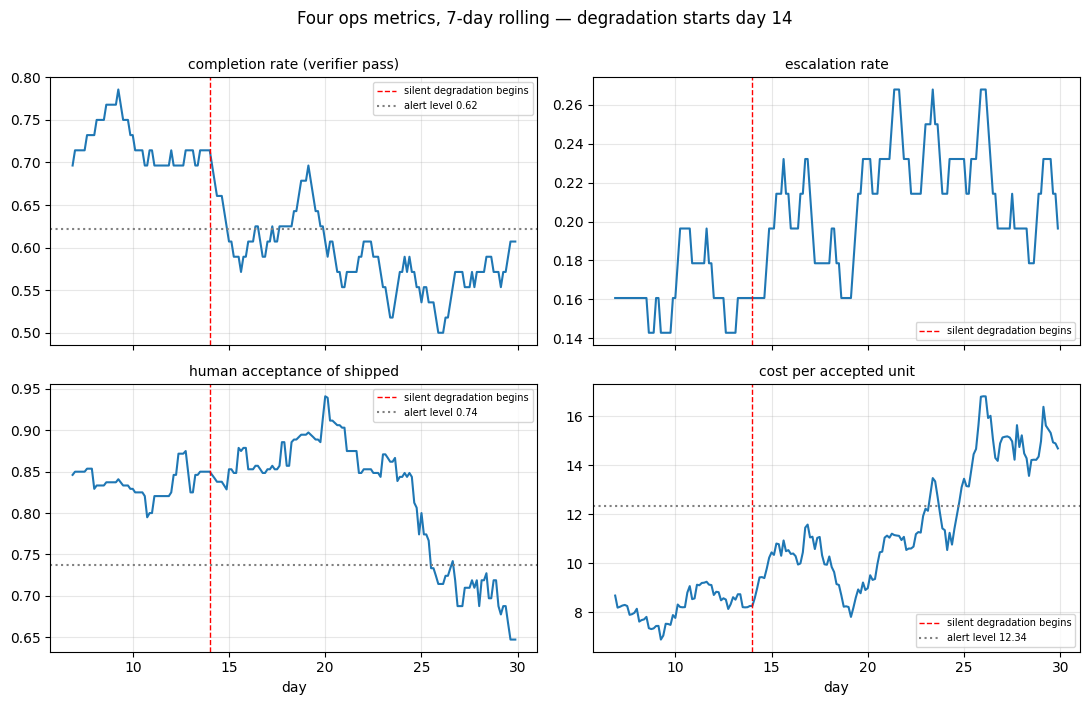

completion  < 0.62 sustained : day 20.0
acceptance  < 0.74 sustained : day 26.8
cost/accept > 12.34 sustained : day 24.8

shipped-but-defective units after day 14: 15  (these are the silent failures the metrics must catch)


In [6]:
days, runs_per_day = 30, 8
n = days * runs_per_day
t = np.arange(n) / runs_per_day            # time in days

# degradation starts day 14: p drifts 0.80 -> 0.45, beta drifts 0.05 -> 0.25
drift = np.clip((t - 14) / 10, 0, 1)
p_true = 0.80 - 0.35 * drift
beta_t = 0.05 + 0.20 * drift
alpha = 0.10

good = rng.random(n) < p_true
passed_good = good & (rng.random(n) >= alpha)
passed_bad = (~good) & (rng.random(n) < beta_t)
shipped = passed_good | passed_bad
escalated = ~shipped & (rng.random(n) < 0.5)   # half of failures escalate, half retry out
# human accepts shipped-good with 0.9, shipped-bad with 0.35 (edits reveal problems slowly)
accepted = shipped & (rng.random(n) < np.where(passed_good, 0.9, 0.35))
cost = rng.gamma(6, 0.5, n) * (1 + 2 * (~shipped))  # failed runs burn extra iterations

def rolling(x, w=7 * runs_per_day):
    return np.convolve(x, np.ones(w) / w, mode="valid")

def rolling_ratio(num, den, w=7 * runs_per_day):
    return rolling(num.astype(float), w) / np.maximum(rolling(den.astype(float), w), 1e-9)

tt = t[len(t) - len(rolling(shipped)):]
comp = rolling(shipped.astype(float))
esc = rolling(escalated.astype(float))
acc = rolling_ratio(accepted, shipped)
cpa = rolling(cost) / np.maximum(rolling(accepted.astype(float)), 1e-9)

# Alert thresholds are calibrated from the loop's own baseline week (first 7 rolling days),
# exactly as an ops runbook would set them — not from a priori round numbers.
base = slice(0, 7 * runs_per_day)
lvl_comp = comp[base].mean() - 0.10          # completion: baseline minus 10 pp
lvl_acc = acc[base].mean() - 0.10            # acceptance: baseline minus 10 pp
lvl_cpa = 1.5 * cpa[base].mean()             # cost/accepted: 1.5x baseline

fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
panels = [
    (comp, "completion rate (verifier pass)", lvl_comp, axes[0, 0]),
    (esc, "escalation rate", None, axes[0, 1]),
    (acc, "human acceptance of shipped", lvl_acc, axes[1, 0]),
    (cpa, "cost per accepted unit", lvl_cpa, axes[1, 1]),
]
for series, name, thresh, ax in panels:
    ax.plot(tt, series)
    ax.axvline(14, ls="--", c="red", lw=1, label="silent degradation begins")
    if thresh is not None:
        ax.axhline(thresh, ls=":", c="gray", label=f"alert level {thresh:.2f}")
    ax.set_title(name, fontsize=10)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7)
axes[1, 0].set_xlabel("day"); axes[1, 1].set_xlabel("day")
fig.suptitle("Four ops metrics, 7-day rolling — degradation starts day 14", y=1.0)
plt.tight_layout()
plt.show()

# Alert = breach *sustained* for >= 2 consecutive days (single crossings are window noise)
def first_sustained(series, level, below=True, hold=2 * runs_per_day):
    breach = series < level if below else series > level
    run = np.convolve(breach.astype(int), np.ones(hold, int), mode="valid")
    idx = np.where(run == hold)[0]
    return f"day {tt[idx[0]]:.1f}" if len(idx) else "never (30d window)"
print(f"completion  < {lvl_comp:.2f} sustained :", first_sustained(comp, lvl_comp))
print(f"acceptance  < {lvl_acc:.2f} sustained :", first_sustained(acc, lvl_acc))
print(f"cost/accept > {lvl_cpa:.2f} sustained :", first_sustained(cpa, lvl_cpa, below=False))
print(f"\nshipped-but-defective units after day 14: {int((passed_bad & (t >= 14)).sum())}"
      f"  (these are the silent failures the metrics must catch)")

**Reading**: the completion rate fires first (~6 days after onset, limited by the 7-day
window plus the 2-day hold), cost-per-accepted follows, and human acceptance lags by nearly
two weeks — edits reveal problems slowly, so the *human* is the slowest sensor in the loop.
Note also that the escalation rate rises far less than the true failure rate: the laxer
verifier ships bad units instead of escalating them, damping exactly the signal you would
naively watch. This is why the playbook pairs escalation with completion and cost, and treats
a *quiet* loop as something to audit, not celebrate.

## Takeaways

1. **Loops are retry distributions**: $P(\text{success within } k) = 1-(1-p)^k$ turns a 20%
   one-shot task into a 95% overnight task at k=14 — no smarter model required.
2. **Size budgets analytically**: $k \geq \ln(1-q)/\ln(1-p)$; hitting the cap means
   decompose the task, not raise the cap.
3. **Verifier false-pass rate $\beta$ is the number that matters**: at loop volume it
   converts directly into silent defects/week; strictness ($\alpha$) only costs linearly.
   Bias reviewers strict; prefer deterministic verifiers.
4. **Respect the cache cliff**: poll under the ~5-min TTL or at 20+ minutes; the 5–20 min
   dead zone pays full re-read prices at polling frequency.
5. **Four rolling metrics (completion, escalation, acceptance, cost/accepted) expose silent
   degradation in days** — and a *falling* escalation rate during degradation is why zero
   escalations should page you.